In [1]:
import sys

print(sys.executable)

/Users/sivani/Desktop/Crop_Ai/ML/venv/bin/python


In [7]:
import pandas as pd

yield_data = pd.read_csv("../datasets/raw/Crop Yeild Data.csv")
soil_data = pd.read_csv("../datasets/raw/state_soil_data.csv")

print(yield_data.shape)
print(soil_data.shape)

(19689, 13)
(30, 5)


In [8]:
print(yield_data["State"].unique())

print(soil_data["state"].unique())

final_data = yield_data.merge(
    soil_data,
    left_on="State",
    right_on="state",
    how="left"
)


print(final_data.head())

print(final_data.shape)

print(final_data.isnull().sum())

<StringArray>
[            'Assam',         'Karnataka',            'Kerala',
         'Meghalaya',       'West Bengal',        'Puducherry',
               'Goa',    'Andhra Pradesh',        'Tamil Nadu',
            'Odisha',             'Bihar',           'Gujarat',
    'Madhya Pradesh',       'Maharashtra',           'Mizoram',
            'Punjab',     'Uttar Pradesh',           'Haryana',
  'Himachal Pradesh',           'Tripura',          'Nagaland',
      'Chhattisgarh',       'Uttarakhand',         'Jharkhand',
             'Delhi',           'Manipur', 'Jammu and Kashmir',
         'Telangana', 'Arunachal Pradesh',            'Sikkim']
Length: 30, dtype: str
<StringArray>
[   'Andhra Pradesh', 'Arunachal Pradesh',             'Assam',
             'Bihar',      'Chhattisgarh',             'Delhi',
               'Goa',           'Gujarat',           'Haryana',
  'Himachal Pradesh',         'Jharkhand', 'Jammu and Kashmir',
         'Karnataka',            'Kerala',    'Madhya

In [9]:
final_data = yield_data.merge(
    soil_data,
    left_on="State",
    right_on="state",
    how="left"
)

final_data.isnull().sum()



Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
state              0
N                  0
P                  0
K                  0
pH                 0
dtype: int64

           Crop  Crop_Year       Season  State     Area  Annual_Rainfall  \
0      Arecanut       1997  Whole Year   Assam  73814.0           2051.4   
1     Arhar/Tur       1997  Kharif       Assam   6637.0           2051.4   
2   Castor seed       1997  Kharif       Assam    796.0           2051.4   
3      Coconut        1997  Whole Year   Assam  19656.0           2051.4   
4  Cotton(lint)       1997  Kharif       Assam   1739.0           2051.4   

   Fertilizer  Pesticide     Yield  Avg_Temperature  Max_Temperature  \
0  7024878.38   22882.34     0.796           23.692           33.435   
1   631643.29    2057.47     0.710           23.692           33.435   
2    75755.32     246.76     0.238           23.692           33.435   
3  1870661.52    6093.36  5238.052           23.692           33.435   
4   165500.63     539.09     0.421           23.692           33.435   

   Min_Temperature   N   P   K   pH  
0           14.779  60  18  38  5.8  
1           14.779  60  18  38  5.

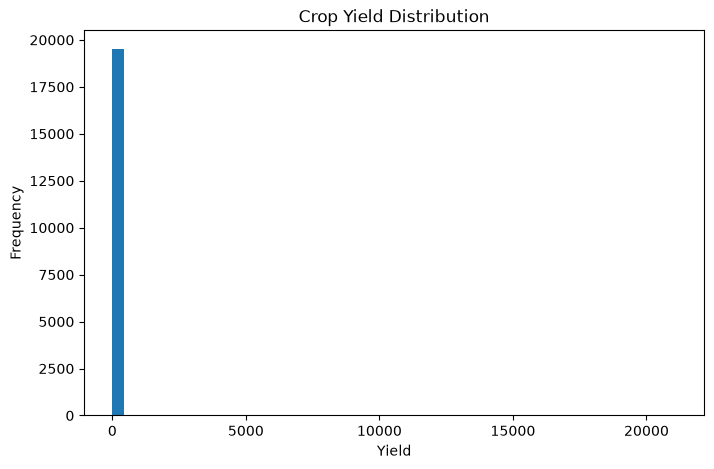

(19689, 15)
(19689,)
Categorical:
Index(['Crop', 'Season', 'State'], dtype='str')

Numerical:
Index(['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide',
       'Avg_Temperature', 'Max_Temperature', 'Min_Temperature', 'N', 'P', 'K',
       'pH'],
      dtype='str')


/var/folders/my/c05p0y095yj5qgc40pnjffdr0000gn/T/ipykernel_6965/1014617546.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [10]:
final_data = final_data.drop(
    columns=["Production", "state"]
)

print(final_data.head())
print(final_data.columns)



import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(final_data["Yield"], bins=50)
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.title("Crop Yield Distribution")
plt.show()



X = final_data.drop("Yield", axis=1)

y = final_data["Yield"]

print(X.shape)
print(y.shape)



categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns


print("Categorical:")
print(categorical_cols)

print("\nNumerical:")
print(numerical_cols)

In [11]:
print(final_data.columns)

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall',
       'Fertilizer', 'Pesticide', 'Yield', 'Avg_Temperature',
       'Max_Temperature', 'Min_Temperature', 'N', 'P', 'K', 'pH'],
      dtype='str')


In [12]:
X = final_data.drop("Yield", axis=1)

y = final_data["Yield"]

print("Features:")
print(X.shape)

print("\nTarget:")
print(y.shape)



categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns


print("Categorical Columns:")
print(list(categorical_cols))

print("\nNumerical Columns:")
print(list(numerical_cols))





Features:
(19689, 15)

Target:
(19689,)
Categorical Columns:
['Crop', 'Season', 'State']

Numerical Columns:
['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature', 'N', 'P', 'K', 'pH']


/var/folders/my/c05p0y095yj5qgc40pnjffdr0000gn/T/ipykernel_6965/1145902881.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

print("Preprocessing pipeline created")

Preprocessing pipeline created


In [14]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print(X_train.shape)
print(X_test.shape)

(15751, 15)
(3938, 15)


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)


print("Random Forest pipeline created")

Random Forest pipeline created


In [16]:
rf_model.fit(
    X_train,
    y_train
)

print("Training completed")

Training completed


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_pred = rf_model.predict(X_test)


mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 10.09999659471809
RMSE: 140.36863936884146
R2 Score: 0.9754089179519998


In [19]:
X_no_area = final_data.drop(
    columns=["Yield", "Area"]
)

y = final_data["Yield"]


categorical_no_area = X_no_area.select_dtypes(
    include=["object"]
).columns


numerical_no_area = X_no_area.select_dtypes(
    exclude=["object"]
).columns


print(X_no_area.shape)
print(categorical_no_area)
print(numerical_no_area)

(19689, 14)
Index(['Crop', 'Season', 'State'], dtype='str')
Index(['Crop_Year', 'Annual_Rainfall', 'Fertilizer', 'Pesticide',
       'Avg_Temperature', 'Max_Temperature', 'Min_Temperature', 'N', 'P', 'K',
       'pH'],
      dtype='str')


/var/folders/my/c05p0y095yj5qgc40pnjffdr0000gn/T/ipykernel_6965/639196862.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_no_area = X_no_area.select_dtypes(


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


X_train, X_test, y_train, y_test = train_test_split(
    X_no_area,
    y,
    test_size=0.2,
    random_state=42
)


preprocessor_no_area = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_no_area
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_no_area
        )
    ]
)


rf_no_area = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_no_area
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)


rf_no_area.fit(
    X_train,
    y_train
)

print("Training completed")

Training completed


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_pred = rf_no_area.predict(X_test)


mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("===== Random Forest Results =====")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

===== Random Forest Results =====
MAE: 10.314084587353957
RMSE: 143.8155401512631
R2 Score: 0.9741863693363659


In [22]:
import sys

print(sys.executable)

import sys

print(sys.executable)

import xgboost

print(xgboost.__version__)

/Users/sivani/Desktop/Crop_Ai/ML/venv/bin/python
/Users/sivani/Desktop/Crop_Ai/ML/venv/bin/python
3.3.0


In [23]:
from xgboost import XGBRegressor


xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_no_area
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                random_state=42
            )
        )
    ]
)


xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed")

XGBoost training completed


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_xgb = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)

mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_xgb)

print("===== XGBoost Results =====")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

===== XGBoost Results =====
MAE: 12.7269
RMSE: 182.8406
R² Score: 0.9583


In [25]:
import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(rf_no_area, "../model/yield_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [28]:
# Verify it was saved

import os

print(os.path.exists("../model/yield_model.pkl"))

True


In [30]:
# Test Loading the Model

loaded_model = joblib.load("../model/yield_model.pkl")

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>
